# Phishing Detection — A Critical Evaluation of the "99% Accuracy" Claim

**Course:** Data Science Methods in Cyber Security (University of Haifa) · Dr. Uri Itai

**Source under evaluation:** Al-Subaiey et al., *"Novel Interpretable and Robust Web-based
AI Platform for Phishing Email Detection"* ([arXiv:2405.11619](https://arxiv.org/abs/2405.11619)) —
which reports **99.1% accuracy / 0.99 F1** with TF-IDF + a Linear SVM on a merged
multi-corpus email dataset, reporting accuracy/precision/recall/F1 but **no MCC, no
ROC-AUC, and no cross-corpus generalization test**.

**Our question.** We reproduce the headline result, then ask whether it reflects
*generalizable phishing detection* or merely *in-distribution performance on this
particular pool of corpora*. This notebook covers **data loading** and **exploratory
data analysis**; the feature engineering, modeling, and the critical-evaluation
experiments follow in later sections.

## 0. Setup

Imports, fixed seed, and a path bootstrap so the notebook runs whether it is launched from the repo root or from `notebooks/`.

In [1]:
import os
import sys
from pathlib import Path

# Make the repo root importable / the working directory, regardless of launch dir.
ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
    os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd

from src import config, data, features, plots

pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 120)
np.random.seed(config.RANDOM_SEED)
print("repo root:", ROOT)
print("random seed:", config.RANDOM_SEED)

repo root: D:\HaifaUni\Cyber Security\Project\phishing-detection-ds-cyber
random seed: 42


## 1. Data Loading

The dataset is the **"Phish No More"** collection (Kaggle: `naserabdullahalam/phishing-email-dataset`),
the source paper's own dataset. It merges six well-known research corpora. We load each
corpus separately and **tag every email with its corpus of origin** — that `corpus`
column is the linchpin of the entire critique, because it lets us later ask whether the
model is detecting *phishing* or *provenance*.

In [2]:
merged = data.build_merged()
print("rows, columns:", merged.shape)
(
    merged.assign(text_preview=merged[config.TEXT_COL].str[:80])
    [[config.CORPUS_COL, config.LABEL_COL, "date", "text_preview"]]
    .head(8)
)

rows, columns: (82486, 4)


,corpus,label,date,text_preview
0,Enron,0,NaT,"hpl nom for may 25 , 2001 ( see attached file : hplno 525 . xls )\r\n- hplno 525 ."
1,Enron,0,NaT,re : nom / actual vols for 24 th - - - - - - - - - - - - - - - - - - - - - - for
2,Enron,0,NaT,"enron actuals for march 30 - april 1 , 201 estimated actuals\r\nmarch 30 , 2001\r\nn"
3,Enron,0,NaT,"hpl nom for may 30 , 2001 ( see attached file : hplno 530 . xls )\r\n- hplno 530 ."
4,Enron,0,NaT,"hpl nom for june 1 , 2001 ( see attached file : hplno 601 . xls )\r\n- hplno 601 ."
5,Enron,0,NaT,hpl nom for may 31 2001 ( see attached file : hplno 531 . xls )\r\n- hplno 531 . x
6,Enron,0,NaT,# 9760 tried to get fancy with your address and it came back to me !\r\n- - - - -
7,Enron,0,NaT,"hpl noms for february 15 , 2000 ( see attached file : hplo 215 . xls )\r\n- hplo 2"


### 1.1 Size and feature types

In [3]:
print("memory (MB):", round(merged.memory_usage(deep=True).sum() / 1e6, 1))
merged.dtypes

memory (MB):

 182.1


text      object
label      int32
date      object
corpus    object
dtype: object

The frame is intentionally minimal: a free-text field (`text` = subject + body), a binary
`label` (1 = phishing, 0 = legitimate), the `corpus` tag we attached, and an optional
`date`. Everything downstream is derived from `text`; `corpus` and `date` are kept for the
critique (provenance and temporal analyses), **not** as model inputs.

### 1.2 Missing values

In [4]:
merged.isna().sum()

text          0
label         0
date      35532
corpus        0
dtype: int64

Only `date` is missing — and its missingness is **informative, not random**: as we show
below, the legitimate-bearing corpora (Enron, Ling) ship with no timestamps at all. This
is a data-quality fact we must respect (it constrains any temporal analysis), exactly the
kind of "*why* is it missing?" question the EDA-Revisited lecture stresses.

### 1.3 Index and column sanity, single-value and duplicate features

In [5]:
print("columns:", list(merged.columns))
print("index is unique:", merged.index.is_unique)
print("\nunique values per column:")
print(merged.nunique())
print("\nfully duplicated rows:", int(merged.duplicated().sum()))
print("duplicated text bodies:", int(merged[config.TEXT_COL].duplicated().sum()))

columns: ['text', 'label', 'date', 'corpus']
index is unique: True

unique values per column:


text      82441
label         2
date      43316
corpus        6
dtype: int64



fully duplicated rows: 23
duplicated text bodies: 45


- **No single-value columns** (none would be useless constants) and **no index masquerading
  as a feature** (the index is a clean RangeIndex; `text` is high-cardinality as expected for
  free text).
- There are some **duplicated text bodies**. Duplicates inflate in-distribution scores if the
  same email lands in both train and test, so we flag this now (tracked in
  `docs/KNOWN_LIMITATIONS.md`) and revisit it when we evaluate.

### 1.4 Temporal coverage

In [6]:
coverage = (
    merged.assign(has_date=merged["date"].notna())
    .groupby(config.CORPUS_COL)
    .agg(n=("date", "size"), with_date=("has_date", "sum"))
)
coverage["pct_dated"] = (coverage["with_date"] / coverage["n"] * 100).round(1)
date_range = (
    merged.dropna(subset=["date"]).groupby(config.CORPUS_COL)["date"].agg(["min", "max"])
)
display(coverage)
display(date_range)

,n,with_date,pct_dated
corpus,,,
CEAS,39154,39139,100.0
Enron,29767,0,0.0
Ling,2859,0,0.0
Nazario,1565,405,25.9
Nigerian_Fraud,3332,2850,85.5
SpamAssassin,5809,4560,78.5


,min,max
corpus,,
CEAS,1980-01-04 05:39:00+00:00,2100-05-27 19:54:05+00:00
Nazario,2015-12-10 14:52:28+00:00,2022-12-27 02:56:49+00:00
Nigerian_Fraud,1980-01-03 10:02:05+00:00,2082-04-02 12:31:31+00:00
SpamAssassin,1997-01-04 00:24:47+00:00,2028-10-04 16:05:01+00:00


**World-knowledge check.** Dates exist only for the phishing/spam-heavy corpora (CEAS-08,
Nazario, Nigerian-Fraud, SpamAssassin); the ham-bearing Enron and Ling corpora are
undated. The dated emails span the mid/late 2000s. This matters twice over: (i) a clean
*cross-class* train-on-past / test-on-future split is impossible (the legitimate side has
no time axis), so our temporal experiment is necessarily **within-corpus**; and (ii) time
and corpus are entangled, which we keep in mind when interpreting any temporal effect.

## 2. Exploratory Data Analysis

We explore the data along four axes: **class balance / prevalence**, **corpus composition**
(the heart of the critique), **content statistics** (phishing vs. legitimate), and
**correlation structure** — finishing with an early, direct signal that the corpora are
stylistically separable.

### 2.1 Class balance and real-world prevalence

counts: {0: 39595, 1: 42891}
prevalence: {0: 0.48, 1: 0.52}


WindowsPath('D:/HaifaUni/Cyber Security/Project/phishing-detection-ds-cyber/figures/class_balance.png')

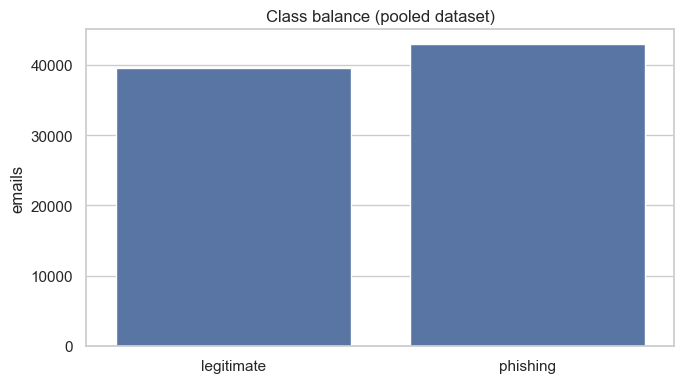

In [7]:
counts = merged[config.LABEL_COL].value_counts().sort_index()
prevalence = (counts / counts.sum()).round(3)
print("counts:", counts.to_dict())
print("prevalence:", prevalence.to_dict())

fig, ax = plots.grouped_bar(
    counts.rename(index={0: "legitimate", 1: "phishing"}),
    title="Class balance (pooled dataset)", ylabel="emails",
)
plots.save_fig(fig, "class_balance")

The pooled dataset is **almost balanced (~52% phishing / 48% legitimate)**. This is a
*constructed* balance, not a natural one: in a real inbox, phishing is **rare** (commonly a
few percent of mail). A balanced test set therefore flatters any classifier, because
**accuracy on balanced data hides the precision problem at realistic prevalence** — a point
the authors do not address, and one we quantify directly in the evaluation section. This is
the classic rare-event pitfall from the *Goodness of Fit* lecture.

### 2.2 Corpus composition — the crux

,legitimate,phishing,%phishing
corpus,,,
Ling,2401,458,16.0
SpamAssassin,4091,1718,29.6
Enron,15791,13976,47.0
CEAS,17312,21842,55.8
Nazario,0,1565,100.0
Nigerian_Fraud,0,3332,100.0


WindowsPath('D:/HaifaUni/Cyber Security/Project/phishing-detection-ds-cyber/figures/corpus_label_crosstab.png')

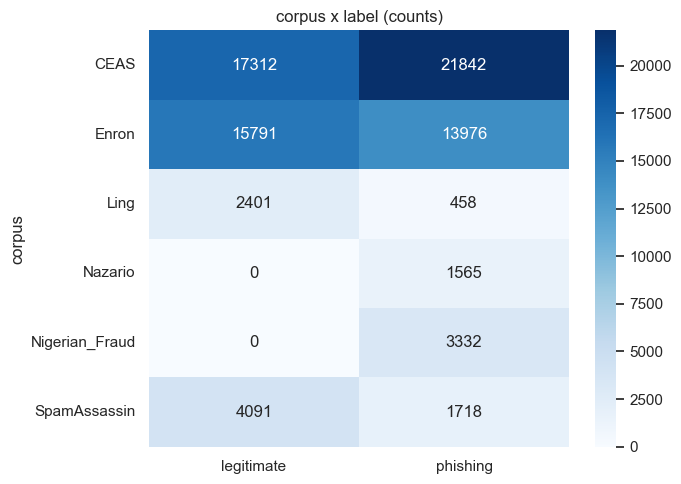

In [8]:
crosstab = pd.crosstab(merged[config.CORPUS_COL], merged[config.LABEL_COL])
crosstab.columns = ["legitimate", "phishing"]
crosstab["%phishing"] = (crosstab["phishing"] / crosstab.sum(axis=1) * 100).round(1)
display(crosstab.sort_values("%phishing"))

fig, ax = plots.heatmap(
    crosstab[["legitimate", "phishing"]], title="corpus x label (counts)",
    fmt="d", cmap="Blues", annot=True, center=None,
)
plots.save_fig(fig, "corpus_label_crosstab")

**This is the single most important table in the project.** A naive reading of these
datasets ("Enron = legitimate, the phishing corpora = phishing") is **false**: these are the
standard *-Spam research corpora, and most contain *both* classes. Only Nazario and
Nigerian-Fraud are phishing-only. So `corpus` is **not** a perfect proxy for `label` — which
means the simplest possible critique ("the model just detects the corpus") does not hold,
and we need a more careful argument about *generalization*. We quantify the corpus↔label
association formally in §2.4.

### 2.3 Content statistics: phishing vs. legitimate

In [9]:
stats = features.add_text_stats(merged)
stats.groupby(config.LABEL_COL)[list(features.TEXT_STAT_COLS)].median().rename(
    index={0: "legitimate", 1: "phishing"}
)

D:\HaifaUni\Cyber Security\Project\phishing-detection-ds-cyber\src\features.py:52: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  out["upper_ratio"] = (text.str.count(r"[A-Z]") / letters).fillna(0.0)


,char_count,word_count,url_count,urgency_count,exclaim_count,upper_ratio
label,,,,,,
legitimate,1116.0,190.0,0.0,0.0,0.0,0.030189
phishing,502.0,89.0,0.0,0.0,0.0,0.032922


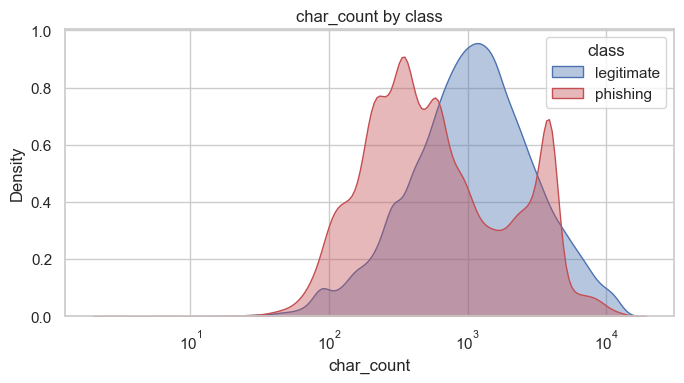

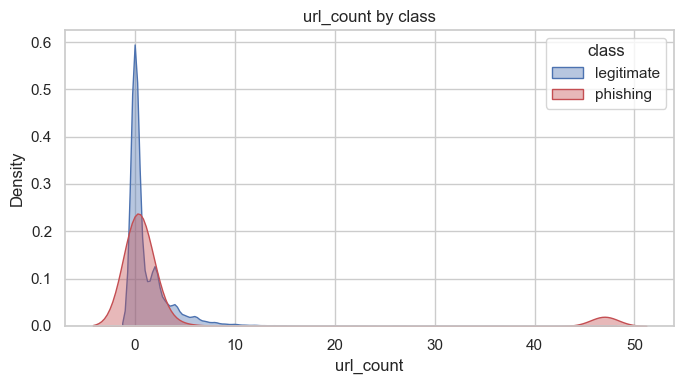

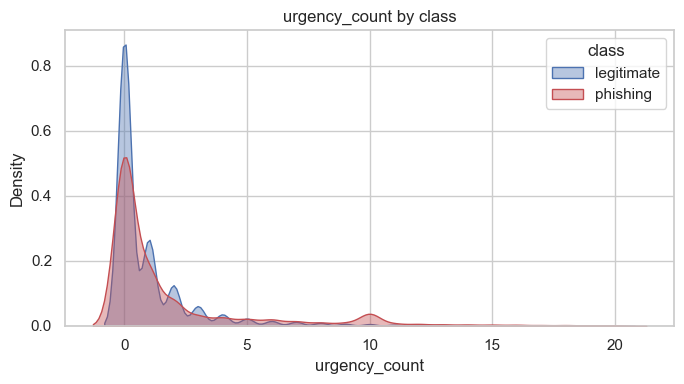

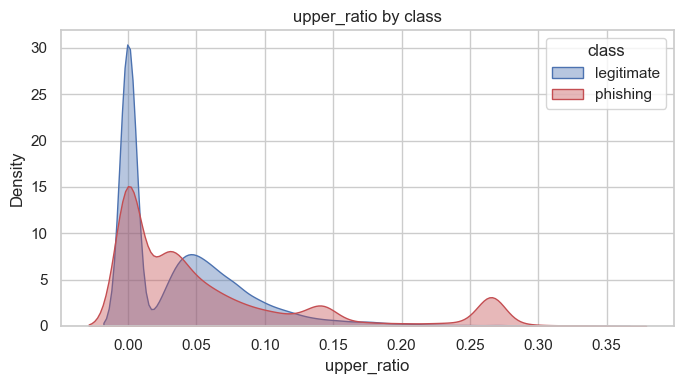

In [10]:
for col, log_x in [("char_count", True), ("url_count", False),
                   ("urgency_count", False), ("upper_ratio", False)]:
    fig, ax = plots.dist_by_class(stats, col, log_x=log_x)
    plots.save_fig(fig, f"dist_{col}")

The hand-features behave the way the Social-Engineering and NLP lectures predict: phishing
messages tend to carry **more URLs**, **more urgency/credential terms**, and heavier
capitalization, while length distributions overlap substantially. These are genuine, if
weak, phishing signals — but note they are also **corpus-correlated** (e.g. Enron's internal
mail is plain and link-free), which foreshadows the leakage concern.

### 2.4 Correlation analysis — and why we choose these measures

We have two kinds of relationship to measure, and they demand different tools:

- **Numeric feature ↔ label.** The hand-features are right-skewed, heavy-tailed counts, and
  the label is binary — so **Pearson** (which assumes linear, roughly-normal relationships)
  is inappropriate. We use **Spearman's ρ**, which captures *monotonic* association via ranks
  and is robust to skew and outliers. **Kendall's τ** would give a similar rank-based reading
  (and is preferred for small samples / many ties); with ~82k rows Spearman is the efficient
  choice, and we note τ as the small-sample alternative.
- **Categorical ↔ categorical** (`corpus` ↔ `label`). Correlation coefficients do not apply
  to nominal variables, so we use **Cramér's V** (derived from the χ² statistic), which scores
  association strength from 0 (independent) to 1 (perfectly associated).

word_count      -0.288872
char_count      -0.266412
url_count       -0.032411
urgency_count    0.086679
upper_ratio      0.111403
exclaim_count    0.247160
Name: label, dtype: float64

Cramers V(corpus, label) = 0.306


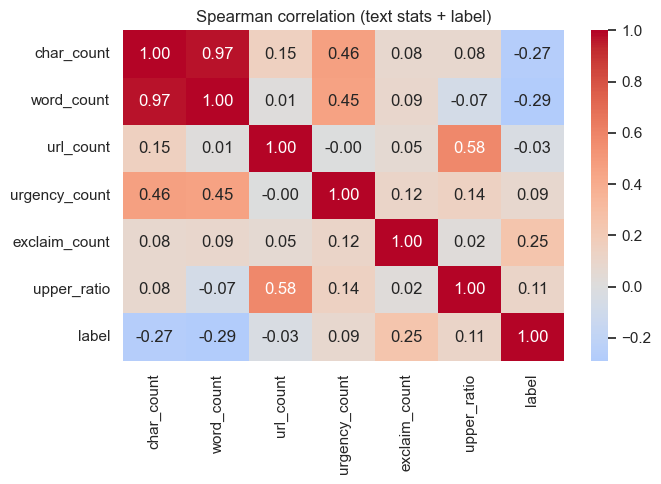

In [11]:
from scipy.stats import chi2_contingency

spearman = stats[list(features.TEXT_STAT_COLS) + [config.LABEL_COL]].corr(method="spearman")
fig, ax = plots.heatmap(spearman, title="Spearman correlation (text stats + label)")
plots.save_fig(fig, "spearman_corr")
display(spearman[config.LABEL_COL].drop(config.LABEL_COL).sort_values())


def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = table.to_numpy().sum()
    r, k = table.shape
    return float(np.sqrt((chi2 / n) / min(r - 1, k - 1)))


print("Cramers V(corpus, label) =", round(cramers_v(merged[config.CORPUS_COL], merged[config.LABEL_COL]), 3))

**Reading the results.** The strongest monotonic correlates of "phishing" among the
hand-features are URL count and urgency-term count — directionally sensible, but **modest**
in magnitude (|ρ| well below 0.5), i.e. statistically clear at this sample size yet not, on
their own, *practically* decisive. The categorical association **Cramér's V(corpus, label) =
0.31** confirms §2.2 quantitatively: corpus is only *moderately* predictive of label, so the
high accuracy is **not** explained by a trivial corpus = label confound. The interesting
question is therefore about generalization, not a single leaky feature.

### 2.5 Early signal: are the corpora stylistically separable?

In [12]:
stats.groupby(config.CORPUS_COL)[list(features.TEXT_STAT_COLS)].median()

,char_count,word_count,url_count,urgency_count,exclaim_count,upper_ratio
corpus,,,,,,
CEAS,598.0,94.0,1.0,0.0,0.0,0.060000
Enron,740.0,157.0,0.0,0.0,0.0,0.000000
Ling,2055.0,406.0,0.0,0.0,0.0,0.000000
Nazario,766.0,108.0,0.0,6.0,0.0,0.079492
Nigerian_Fraud,2564.5,433.0,0.0,7.0,0.0,0.061179
SpamAssassin,1123.0,160.0,2.0,1.0,0.0,0.065711


Even on six crude hand-features, the corpora have **visibly different fingerprints** (message
length, link density, capitalization). If sources are this separable on six features, they
are trivially separable in a high-dimensional TF-IDF space — which is precisely how a model
can post 99% in-distribution while latching onto *source-specific* vocabulary rather than
*phishing* semantics. We make this rigorous in the critique section, where we (i) train a
classifier to predict the **corpus** from text, (ii) inspect which tokens the phishing model
relies on, and (iii) test **leave-one-corpus-out** generalization.

### Section takeaways
- The dataset is balanced by construction (~52/48), unlike a real inbox — accuracy will
  flatter the model.
- Most corpora are **mixed**-label; only Nazario/Nigerian-Fraud are phishing-only, so
  `corpus ≠ label` (Cramér's V = 0.31). The naive confound story is retired here.
- Timestamps exist only on the phishing-heavy corpora, constraining temporal analysis.
- Hand-features carry real but modest phishing signal — and are corpus-correlated.
- The corpora are **stylistically separable**, setting up the generalization critique.